<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/Customer_Segments_Profiling_and_Statistical_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text, inspect
from google.colab import userdata

engine = create_engine(userdata.get("NEON_DATABASE_URL"))

query = """
SELECT *
FROM v_segmented_data
"""

df = pd.read_sql(text(query), con = engine)
print("Preview of data pulled from Postgres database")
df.head()

Preview of data pulled from Postgres database


,CustomerID,CohortMonth,Recency,Frequency,TotalRevenue,Tenure,ProductDiversity,KSegment
0,12346.0,2011-01,325,1,77183.60,0,1,1
1,12347.0,2010-12,129,5,2790.86,238,82,2
2,12348.0,2010-12,248,3,1487.24,110,22,0
3,12350.0,2011-02,310,1,334.40,0,17,0
4,12352.0,2011-02,262,4,1561.81,34,26,0


In [79]:
df.groupby("KSegment").agg(
  customer_count = ("CustomerID", "count"),
  percentage = ("CustomerID", lambda x : f"{len(x)/ len(df) * 100:.1f} %"),
  median_revenue = ("TotalRevenue", "median"),
  median_tenure = ("Tenure", "median"),
  median_recency = ("Recency", "median"),
  median_frequency = ("Frequency", "median"),
  median_diversity = ("ProductDiversity", "median")).reset_index()

,KSegment,customer_count,percentage,median_revenue,median_tenure,median_recency,median_frequency,median_diversity
0,0,2018,60.8 %,312.30,0.0,220.0,1.0,18.0
1,1,20,0.6 %,45618.62,261.5,107.0,29.5,368.5
2,2,1279,38.6 %,1501.82,186.0,127.0,4.0,66.0


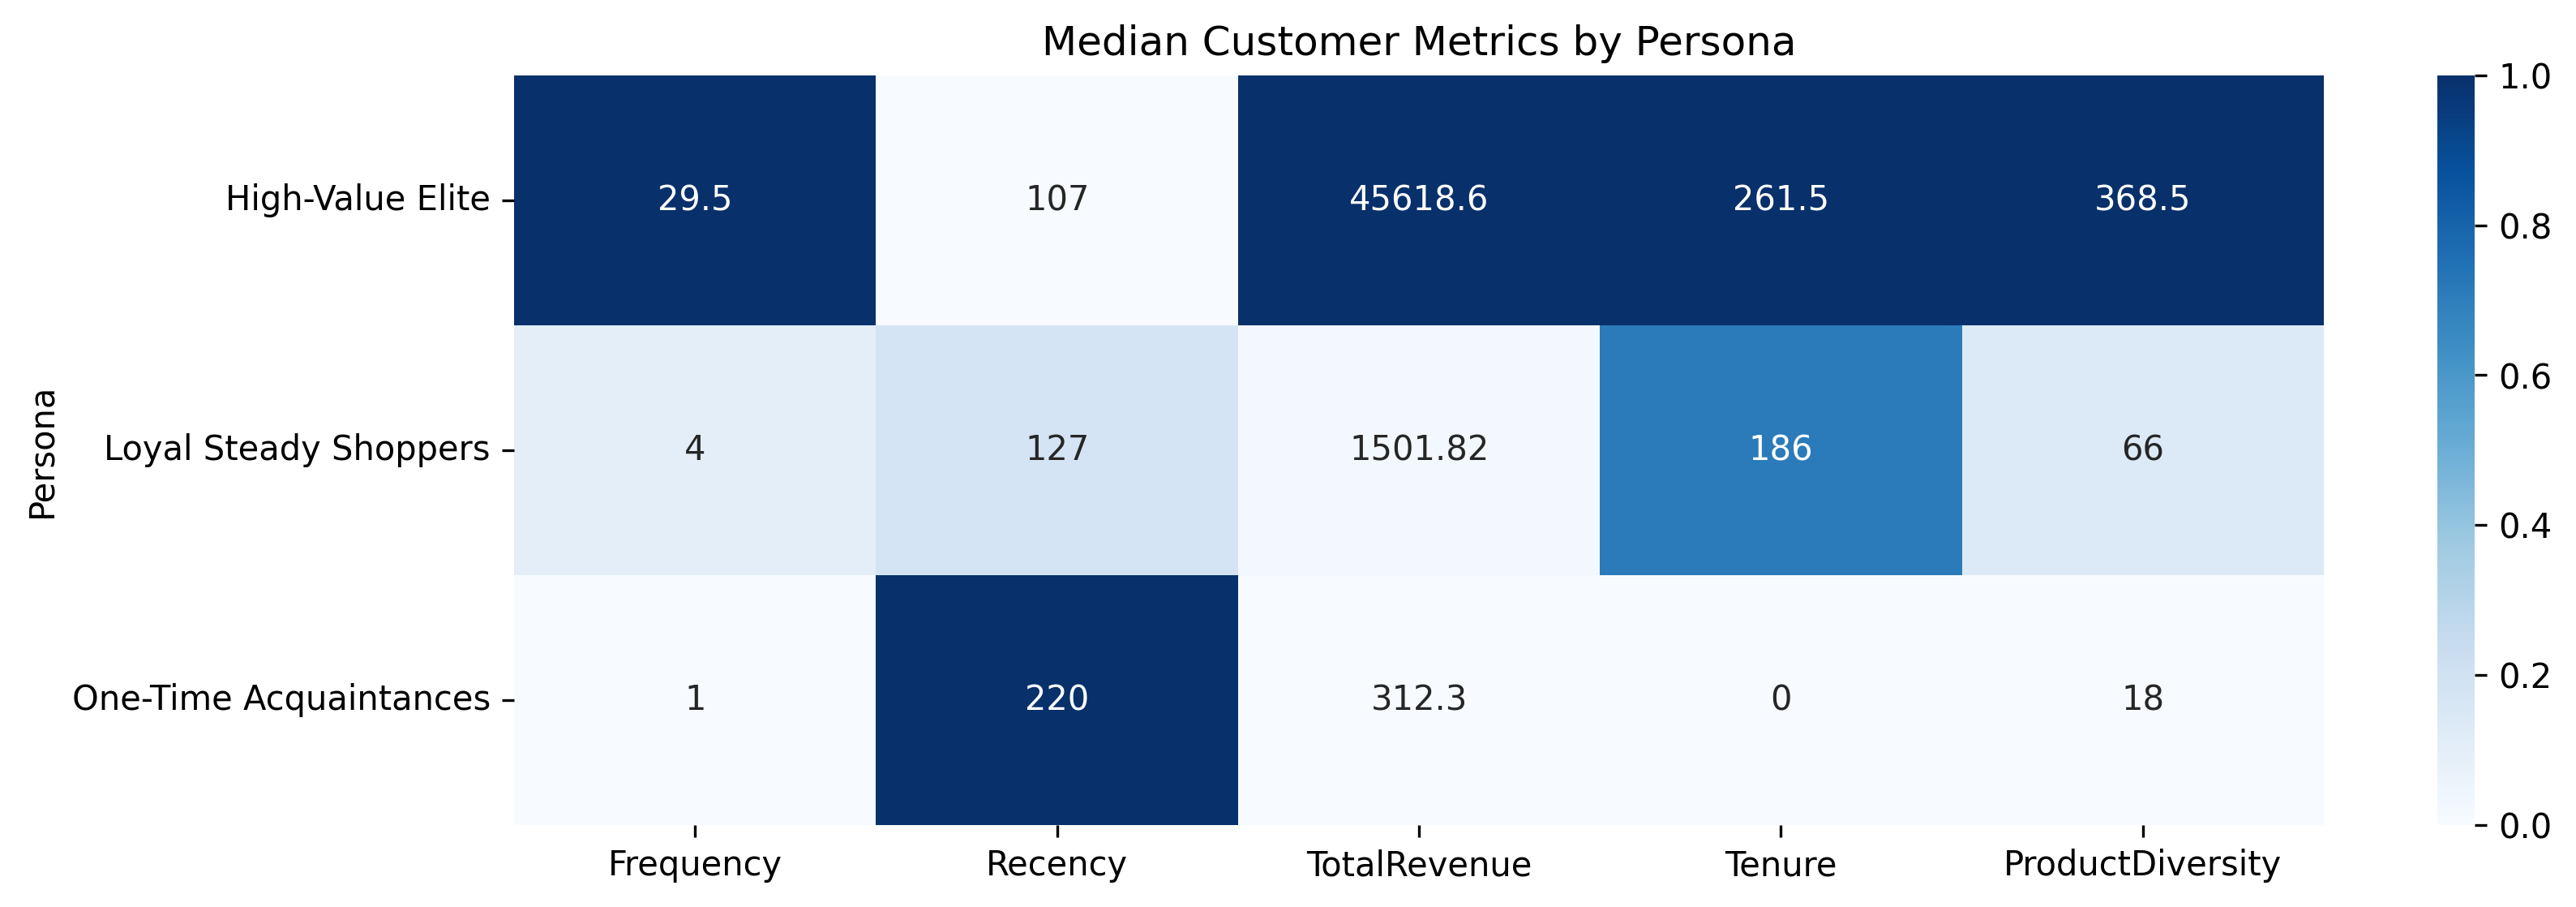

In [80]:
persona_mapping = {
    0: "One-Time Acquaintances",
    1: "High-Value Elite",
    2: "Loyal Steady Shoppers"
}
df['Persona'] = df['KSegment'].map(persona_mapping)

medians = df.groupby("Persona")[['Frequency', 'Recency', 'TotalRevenue', 'Tenure', 'ProductDiversity']].median()
medians_norm = (medians - medians.min())/(medians.max() - medians.min())

plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(data = medians_norm, annot = medians, fmt = 'g', cmap = 'Blues')
plt.title('Median Customer Metrics by Persona')
plt.show()

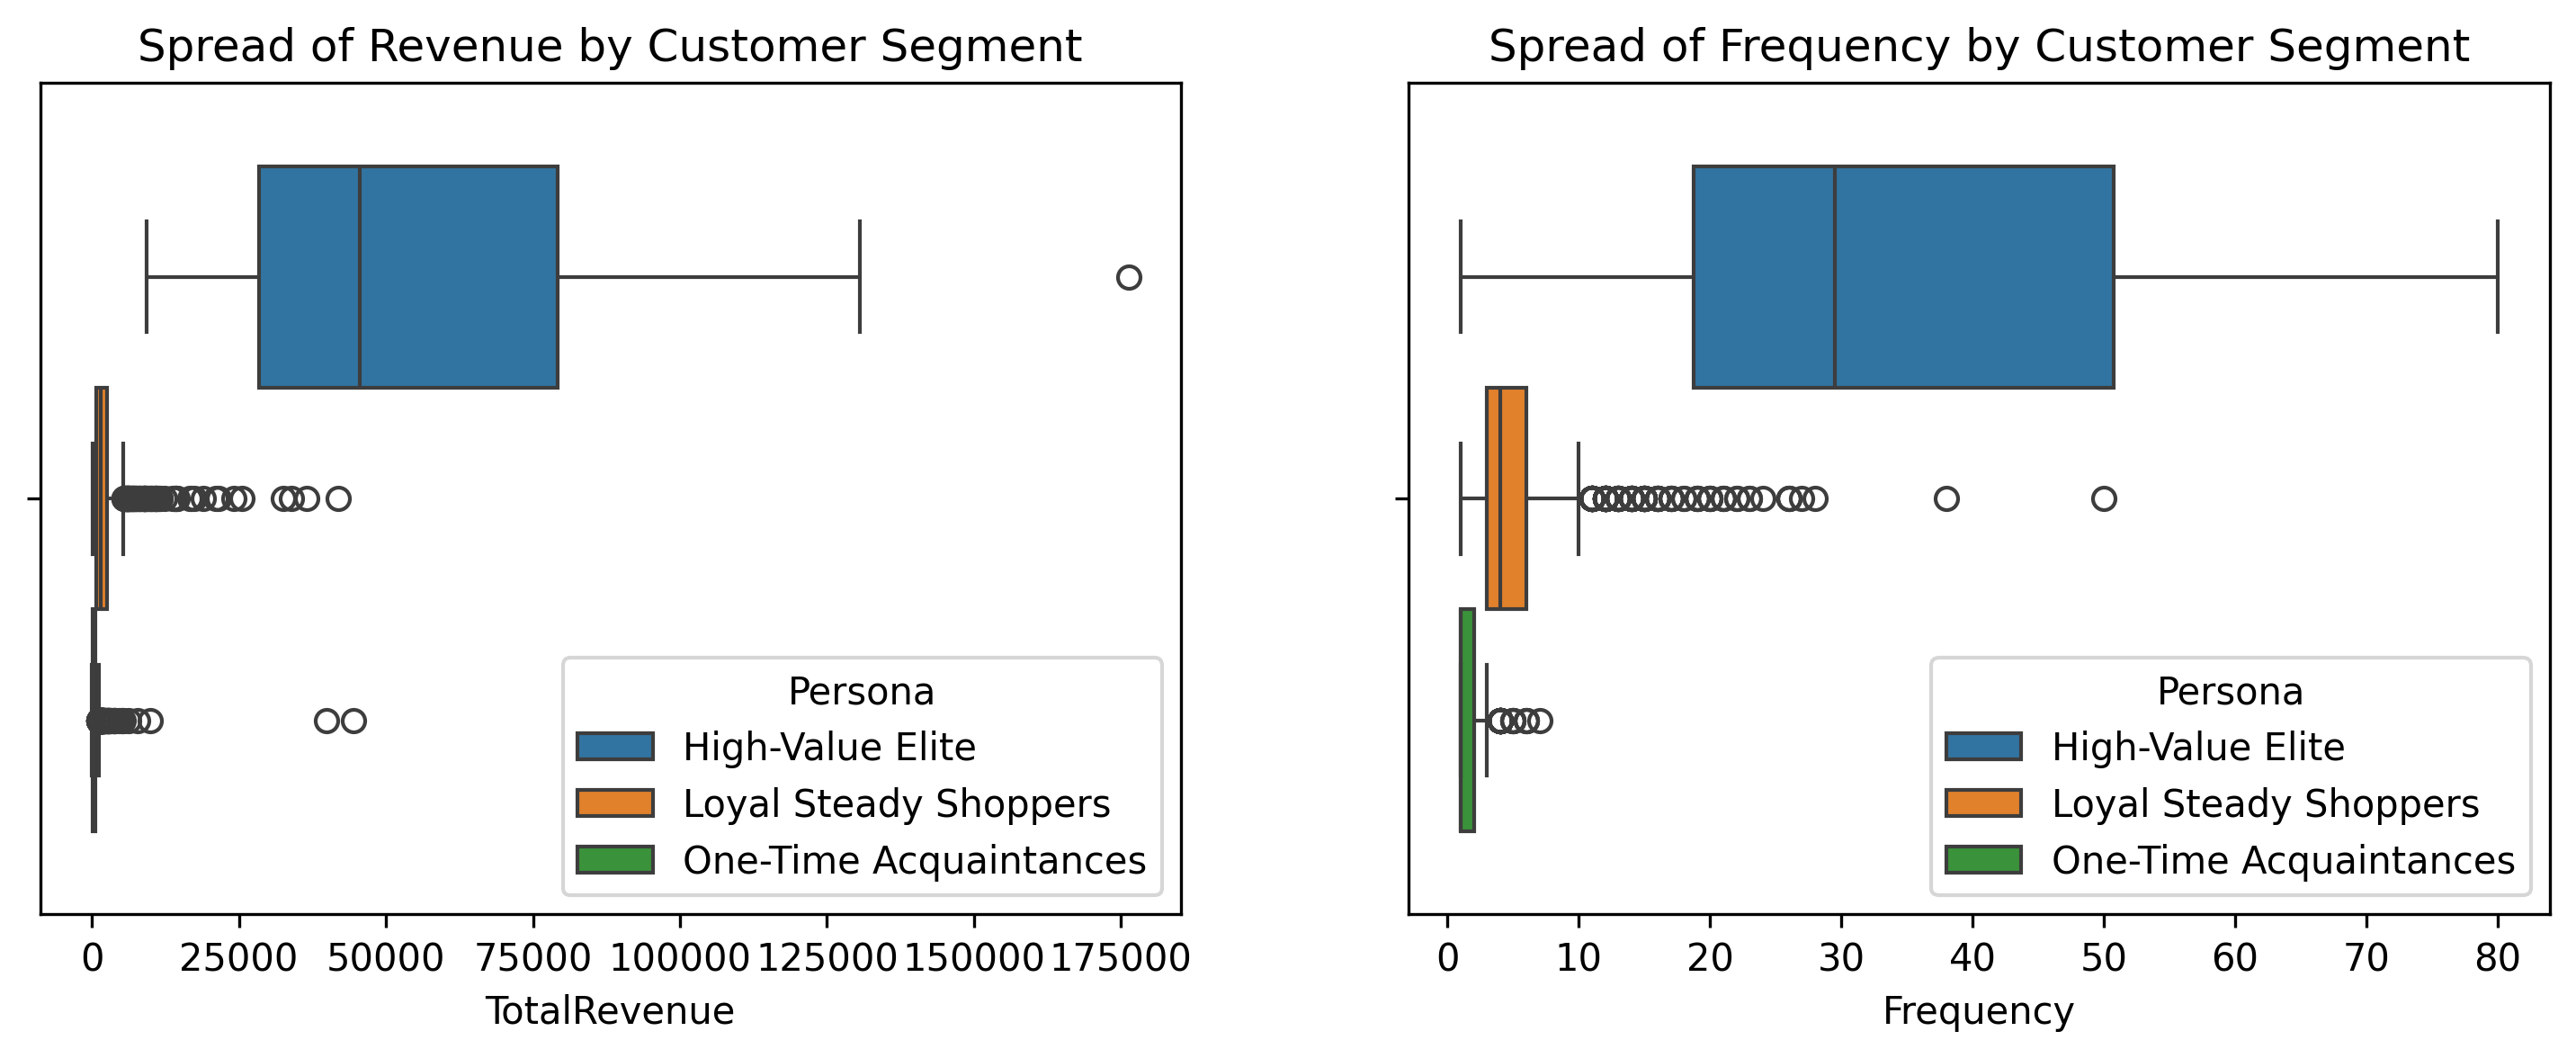

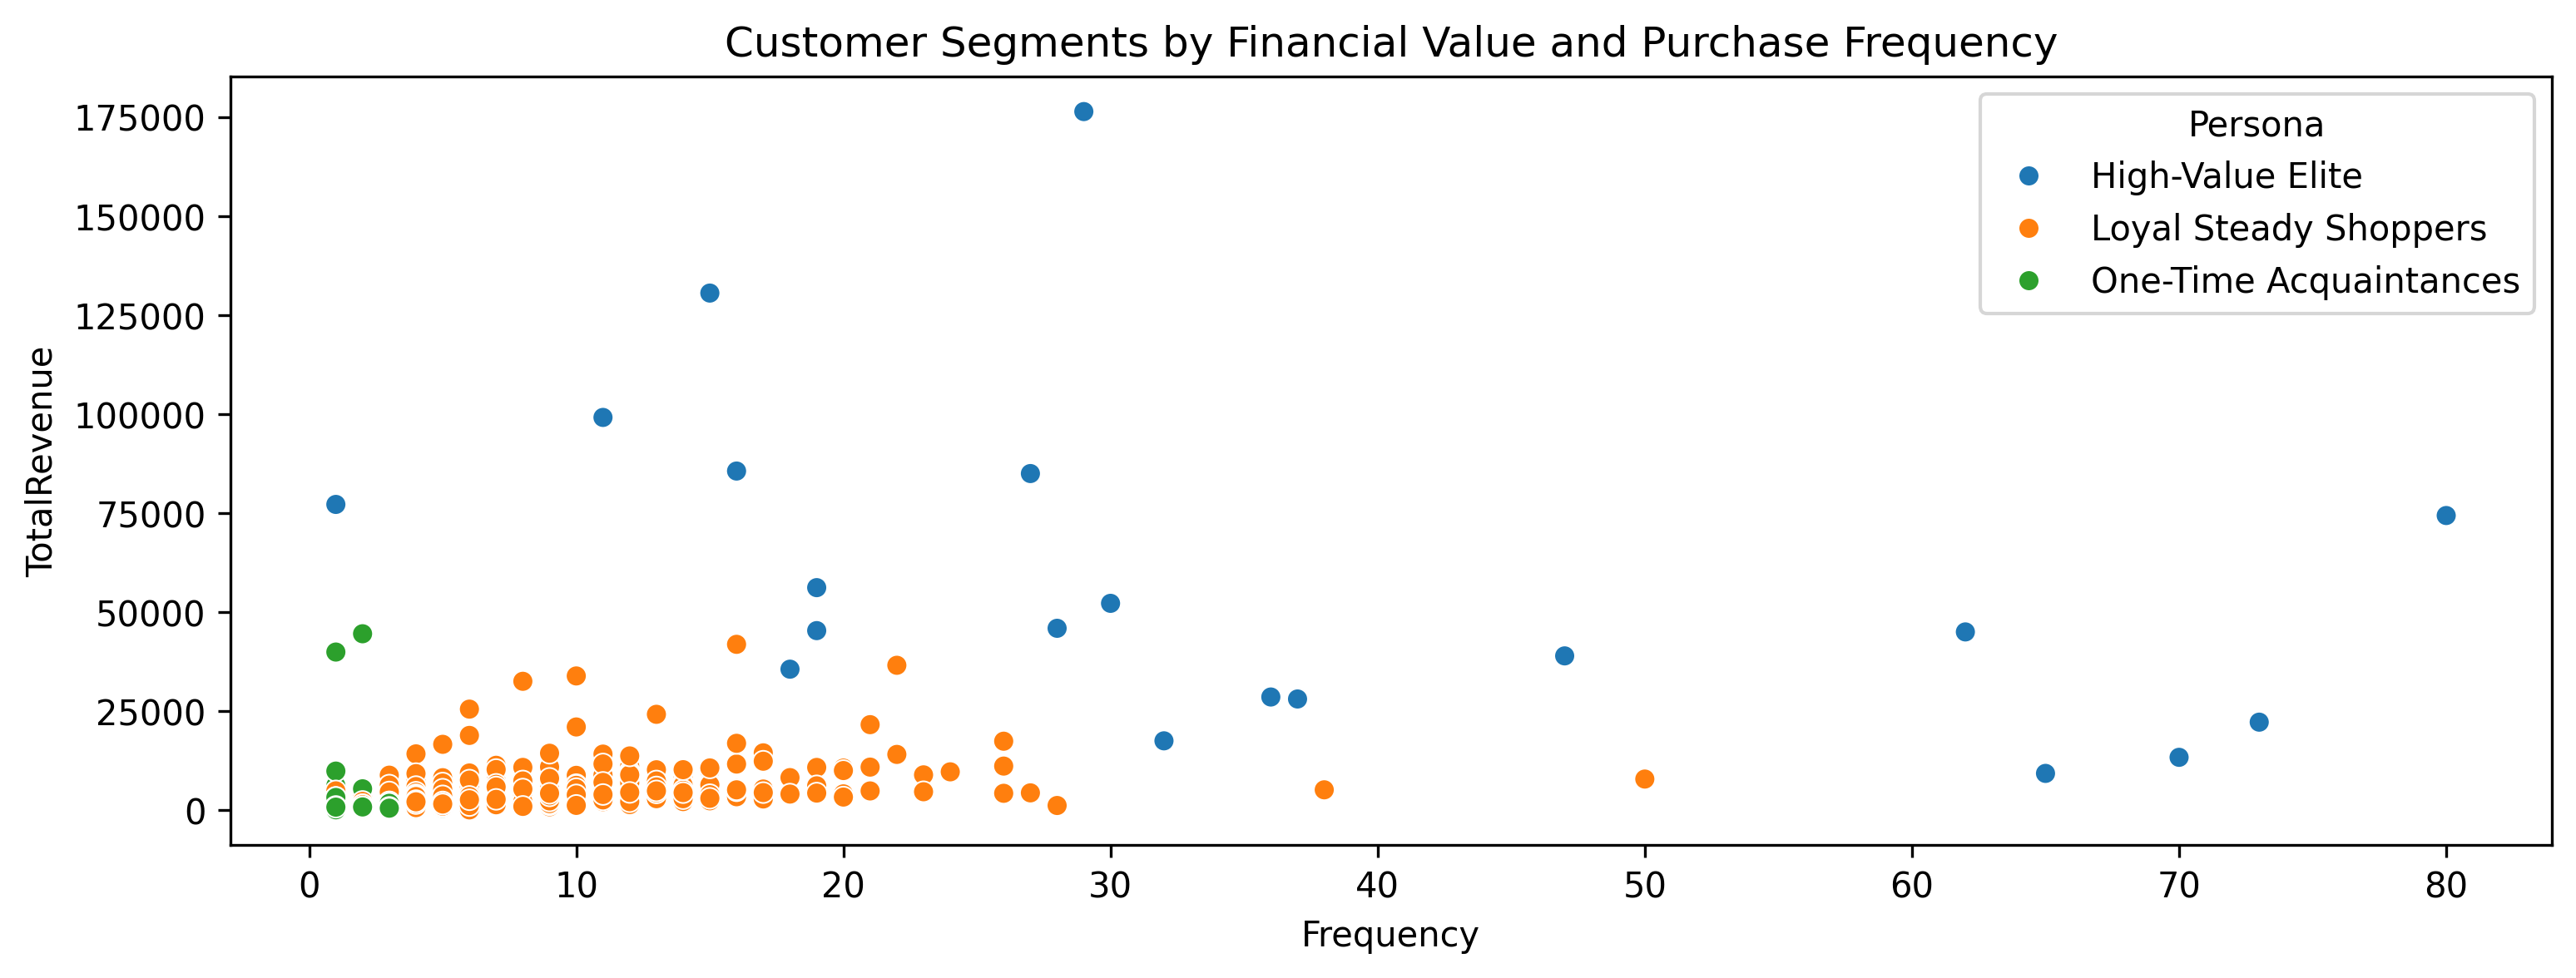

In [81]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,4), dpi = 300)

sns.boxplot(data = df, x = 'TotalRevenue', hue = 'Persona', legend = True, ax = ax1)
ax1.set_title('Spread of Revenue by Customer Segment')

sns.boxplot(data = df, x = 'Frequency', hue = 'Persona', legend = True, ax = ax2)
ax2.set_title('Spread of Frequency by Customer Segment')

plt.show()

plt.figure(figsize = (12,4), dpi = 300)
sns.scatterplot(data = df,
                y = 'TotalRevenue',
                x = 'Frequency',
                hue = 'Persona'
                )
plt.title('Customer Segments by Financial Value and Purchase Frequency')
plt.show()


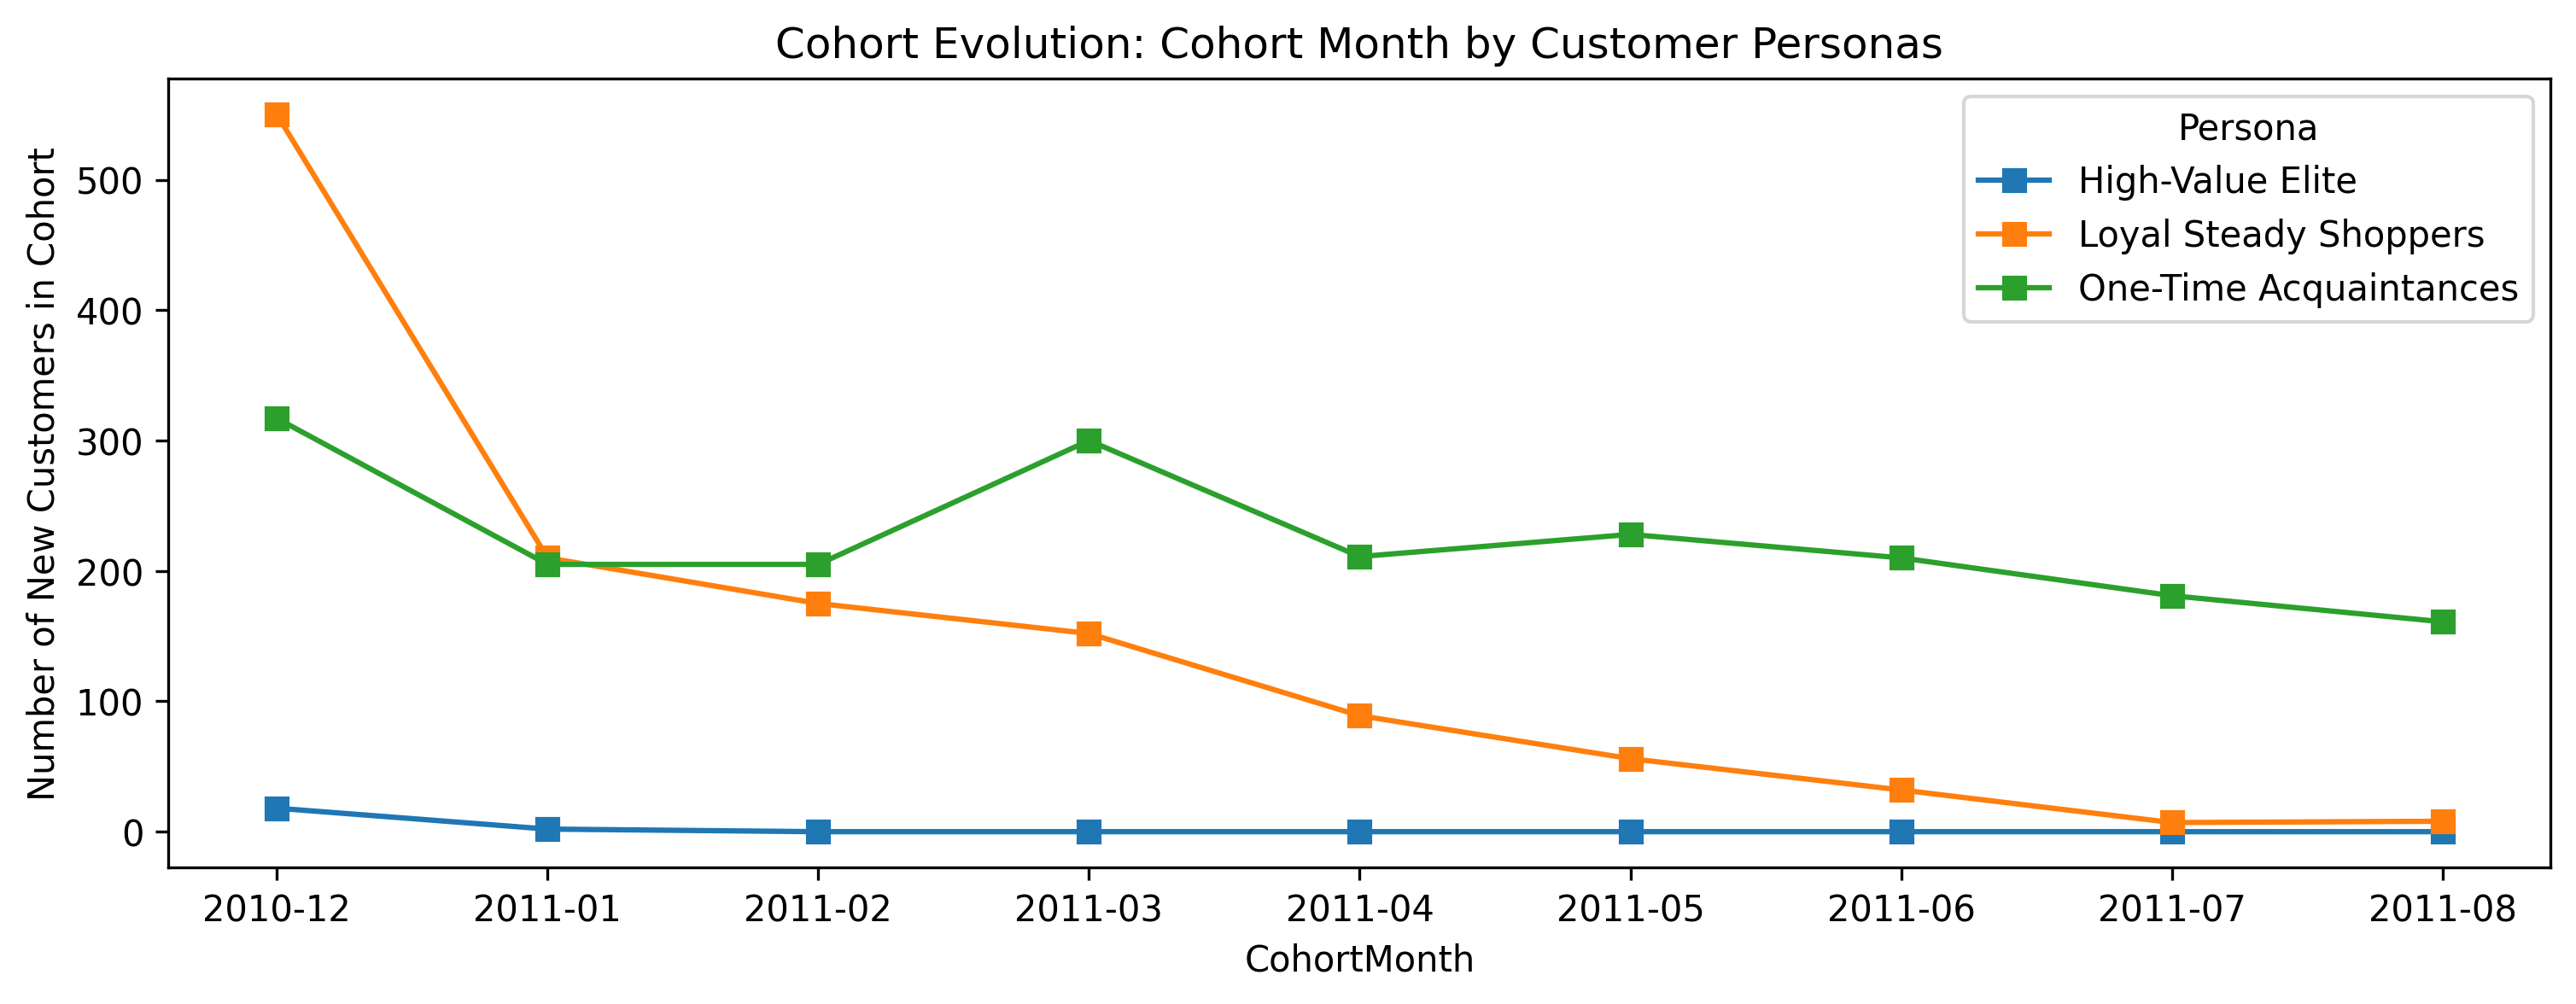

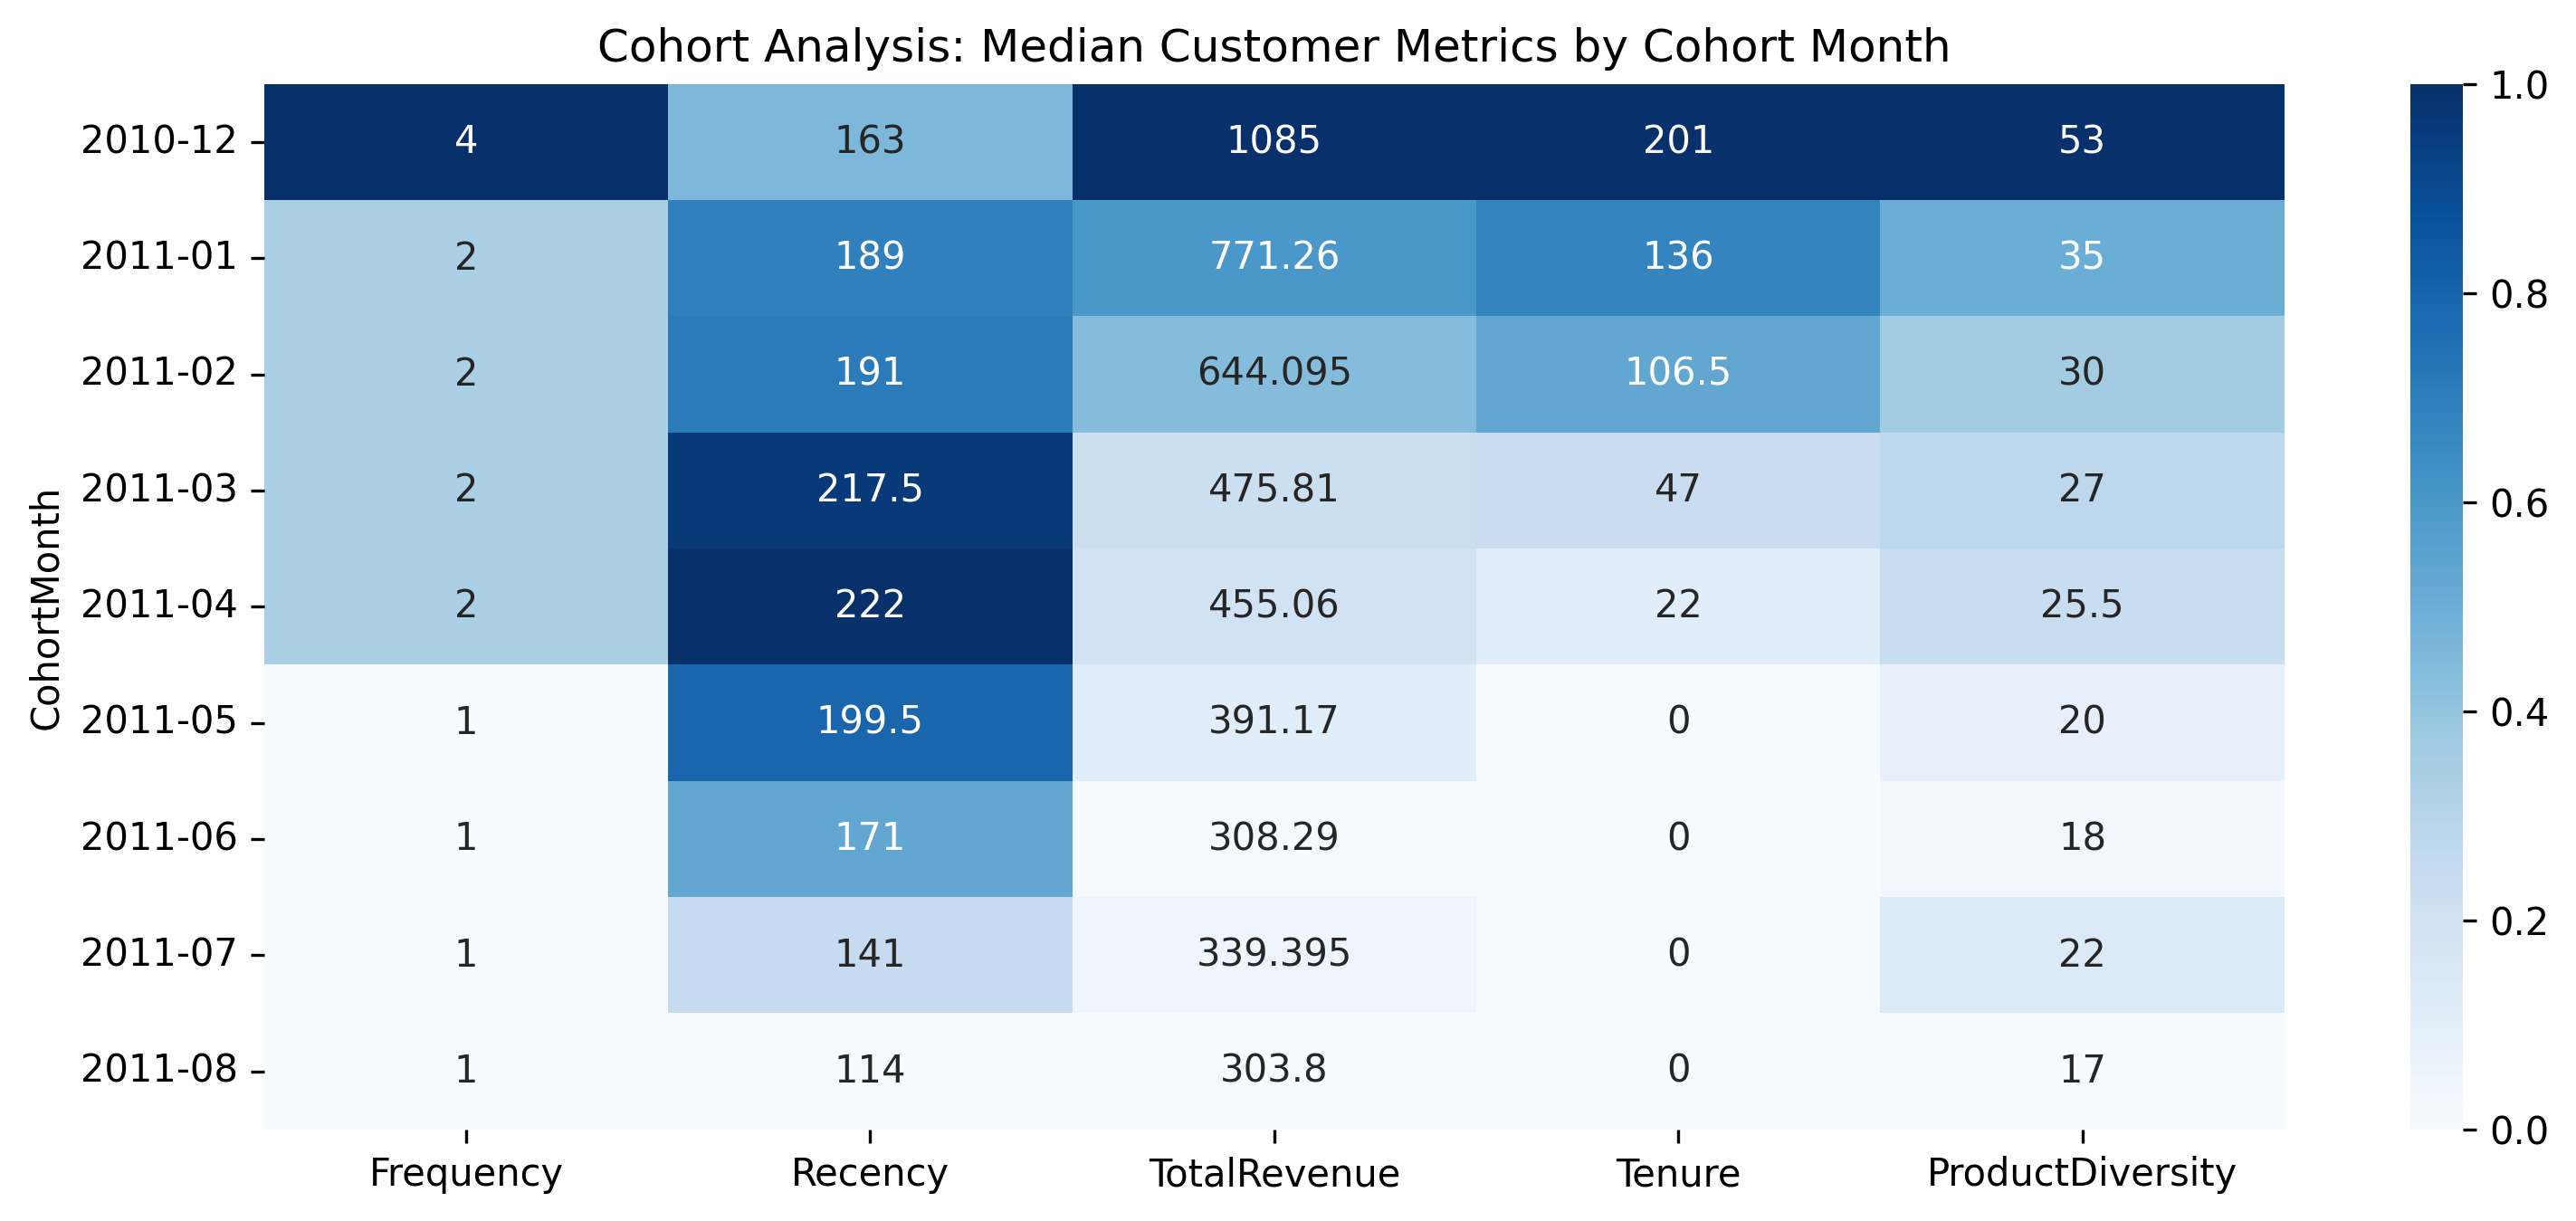

In [82]:
cohort_crosstab = pd.crosstab(df['CohortMonth'], df['Persona'])

plt.figure(figsize = (12,4), dpi = 300)
cohort_crosstab.plot(kind = 'line', ax = plt.gca(), marker = 's')
plt.title('Cohort Evolution: Cohort Month by Customer Personas')
plt.ylabel('Number of New Customers in Cohort')
plt.show()

medians = df.groupby("CohortMonth")[['Frequency', 'Recency', 'TotalRevenue', 'Tenure', 'ProductDiversity']].median()
medians_norm = (medians - medians.min())/(medians.max() - medians.min())

plt.figure(figsize = (12,5), dpi = 300)
sns.heatmap(data = medians_norm, annot = medians, fmt = 'g', cmap = 'Blues')
plt.title('Cohort Analysis: Median Customer Metrics by Cohort Month')
plt.show()

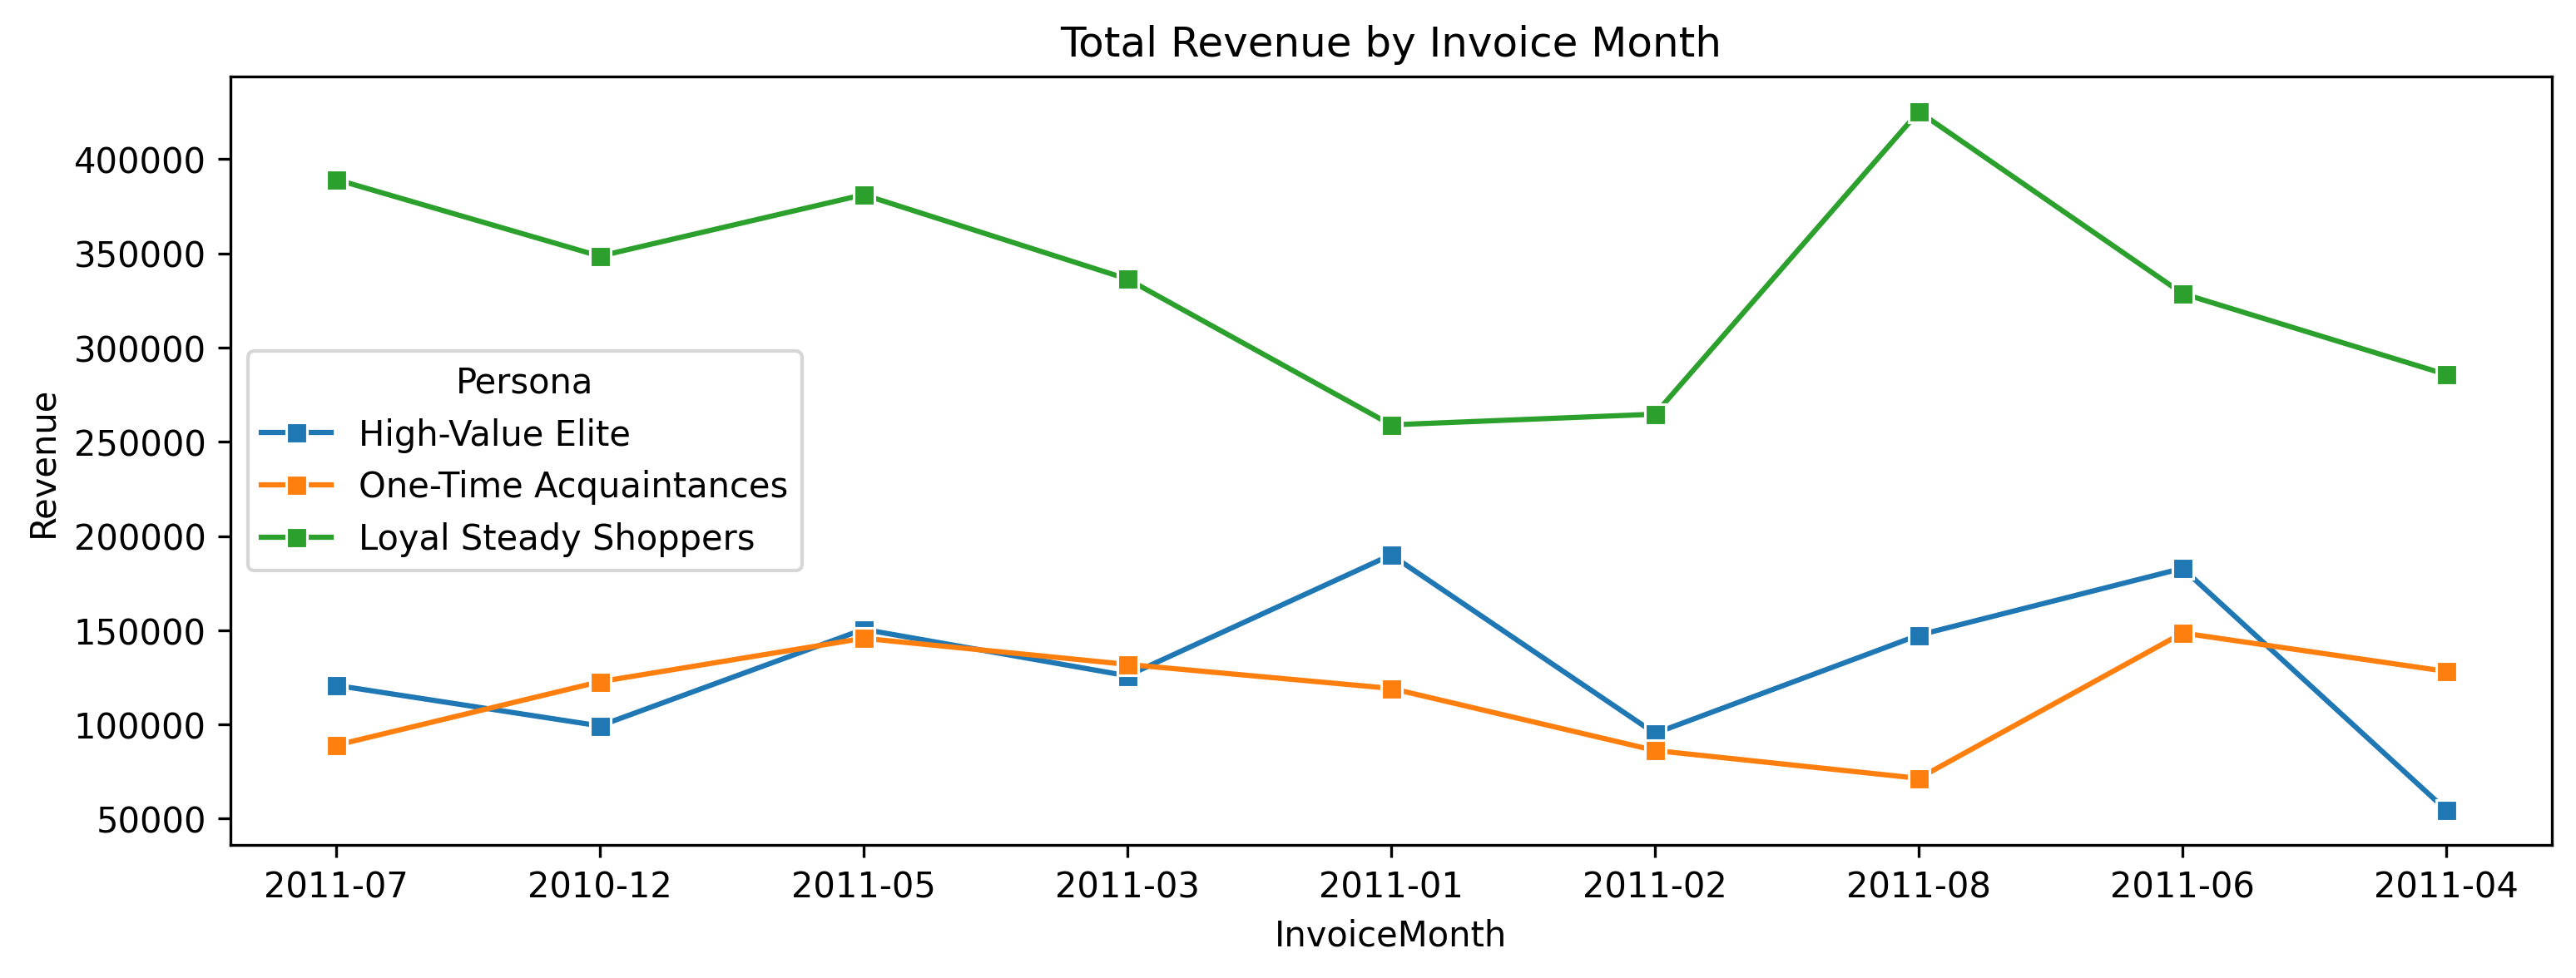

In [116]:
engine = create_engine(userdata.get('NEON_DATABASE_URL'))
query ="""
WITH data AS
(SELECT "CustomerID",
  TO_CHAR("InvoiceDate", 'YYYY-MM') AS "InvoiceMonth",
  "Revenue",
  "KSegment"
FROM v_clean_sales_analytics
LEFT JOIN (SELECT *
          FROM customer_segment_labels)
USING("CustomerID")
WHERE "InvoiceDate" <= '2011-08-31')

SELECT "InvoiceMonth",
  "KSegment",
  SUM("Revenue") AS "Revenue"
FROM data
GROUP BY "InvoiceMonth", "KSegment"
"""

rev_df = pd.read_sql(text(query), con = engine)
rev_df['Persona'] = rev_df['KSegment'].map(persona_mapping)

plt.figure(figsize= (12,4), dpi = 300)
sns.lineplot(data = rev_df, x = "InvoiceMonth", y = "Revenue",
             estimator = 'sum', errorbar = None, hue = 'Persona',
             marker = 's')
plt.title("Total Revenue by Invoice Month and Customer Segment")
plt.show()
